In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Mental_Health_Lifestyle_Dataset.csv")


print(df.shape)
display(df.head())


(3000, 12)


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


<Figure size 800x500 with 0 Axes>

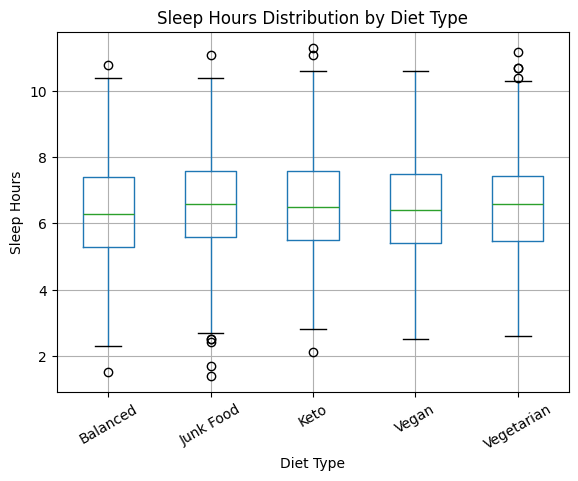

In [ ]:
plt.figure(figsize=(8,5))
df.boxplot(column="Sleep Hours", by="Diet Type")

plt.title("Sleep Hours Distribution by Diet Type")
plt.suptitle("")
plt.xlabel("Diet Type")
plt.ylabel("Sleep Hours")
plt.xticks(rotation=30)
plt.show()

<Figure size 800x500 with 0 Axes>

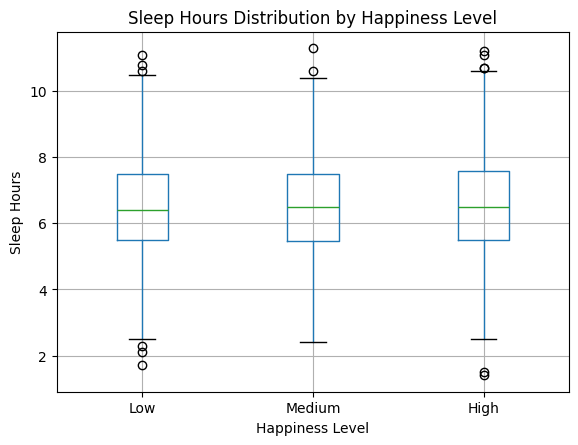

In [ ]:

# Create happiness categories
df["Happiness Level"] = pd.cut(
    df["Happiness Score"],
    bins=[0, 4, 7, 10],
    labels=["Low", "Medium", "High"]
)
plt.figure(figsize=(8,5))
df.boxplot(column="Sleep Hours", by="Happiness Level")

plt.title("Sleep Hours Distribution by Happiness Level")
plt.suptitle("")
plt.xlabel("Happiness Level")
plt.ylabel("Sleep Hours")
plt.show()



In [ ]:
import altair as alt

# Filter dataset to only women
women_data = df[df["Gender"] == "Female"]

In [ ]:

women_data = df[df["Gender"] == "Female"]

chart1 = alt.Chart(women_data).mark_boxplot(size=60).encode(
    x=alt.X("Stress Level:N", title="Stress Level"),
    y=alt.Y("Happiness Score:Q", title="Happiness Score"),
    color="Stress Level:N",
    tooltip=["Stress Level","Happiness Score"]
).properties(
    title="Happiness Scores for Women Across Stress Levels",
    width=400,
    height=400
)

chart1

alt.Chart(...)

In [ ]:
chart2 = alt.Chart(women_data).mark_boxplot(size=60).encode(

    x=alt.X("Exercise Level:N", sort=["Low","Moderate","High"], title="Exercise Level"),

    y=alt.Y("Happiness Score:Q", title="Happiness Score"),

    column=alt.Column("Stress Level:N", title="Stress Level"),

    color=alt.Color("Stress Level:N", title="Stress Level"),

    tooltip=["Exercise Level","Happiness Score","Stress Level"]

).properties(
    title="Exercise Level and Happiness for Women Within Each Stress Level",
    width=250,
    height=350
)
chart2

alt.Chart(...)

In [ ]:
chart3 = alt.Chart(women_data).mark_boxplot(size=60).encode(

    x=alt.X("Stress Level:N", title="Stress Level"),

    y=alt.Y("Happiness Score:Q", title="Happiness Score"),

    column=alt.Column("Exercise Level:N", sort=["Low","Moderate","High"], title="Exercise Level"),

    color=alt.Color("Stress Level:N", title="Stress Level"),

    tooltip=["Exercise Level","Happiness Score","Stress Level"]

).properties(
    title="Stress Level and Happiness for Women Within Each Exercise Level",
    width=250,
    height=350
)

chart3

alt.Chart(...)

In [ ]:
final_chart = chart1 & chart2 & chart3
final_chart

alt.VConcatChart(...)